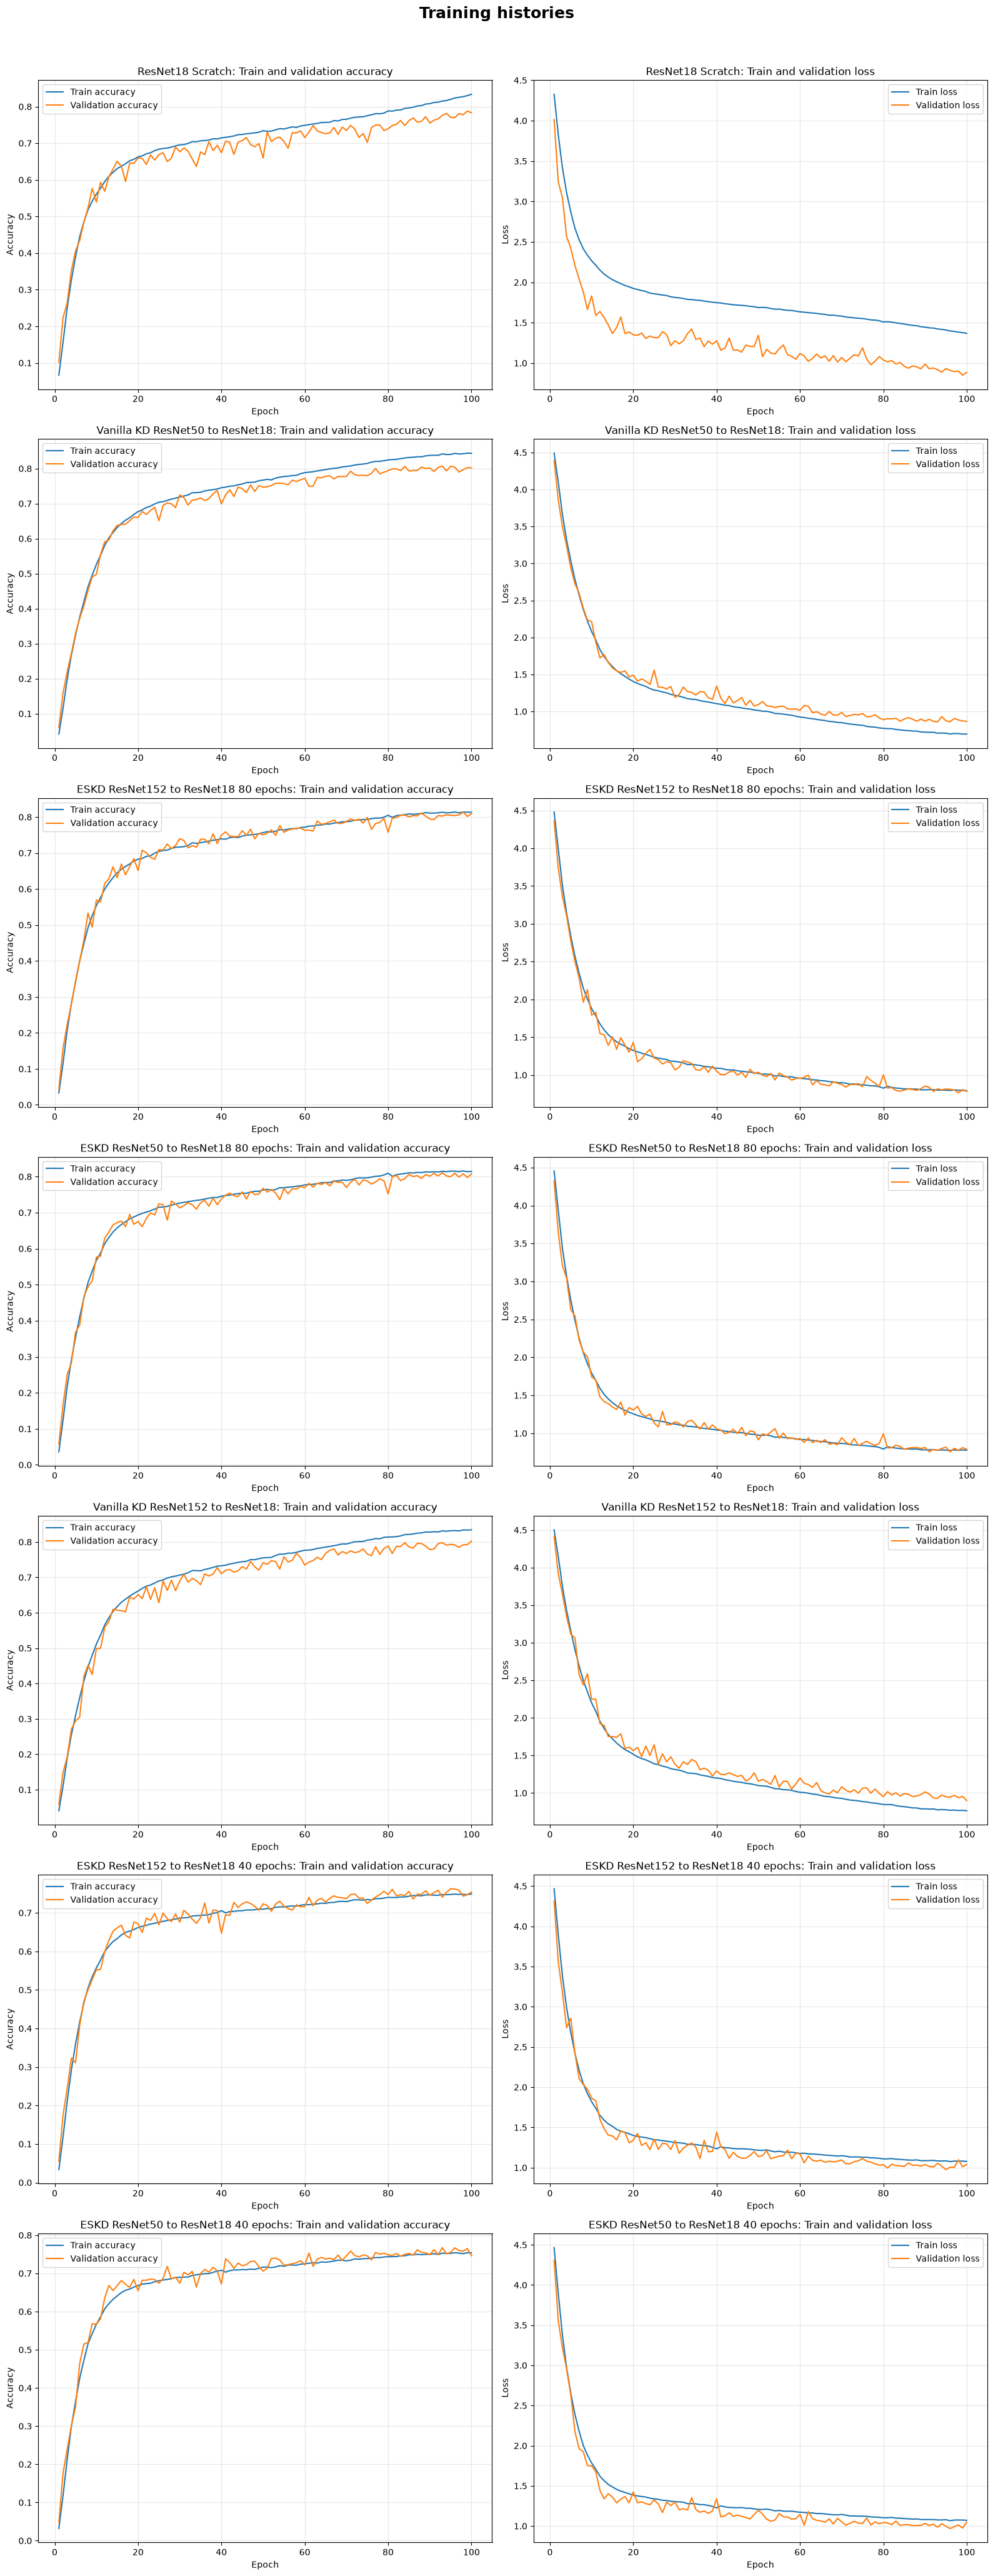

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем историю обучения
histories = [
    ("../data/weights/resnet18_imagenet100/scratch/history.csv", "ResNet18 Scratch"),
    ("../data/weights/resnet18_imagenet100/vanilla-KD_resnet50/history.csv", "Vanilla KD ResNet50 to ResNet18"),
    ("../data/weights/resnet18_imagenet100/ESKD_resnet152_80_epochs/history.csv", "ESKD ResNet152 to ResNet18 80 epochs"),
    ("../data/weights/resnet18_imagenet100/ESKD_resnet50_80_epochs/history.csv", "ESKD ResNet50 to ResNet18 80 epochs"),
    ("../data/weights/resnet18_imagenet100/vanilla-KD_resnet152/history.csv", "Vanilla KD ResNet152 to ResNet18"),
    ("../data/weights/resnet18_imagenet100/ESKD_resnet152_40_epochs/history.csv", "ESKD ResNet152 to ResNet18 40 epochs"),
    ("../data/weights/resnet18_imagenet100/ESKD_resnet50_40_epochs/history.csv", "ESKD ResNet50 to ResNet18 40 epochs")
]

fig, axes = plt.subplots(
    nrows=len(histories),
    ncols=2,
    figsize=(16, 6 * len(histories)),
    squeeze=False,
)

for row, (history_path, history_exp_name) in enumerate(histories):
    history = pd.read_csv(history_path)

    accuracy_ax = axes[row, 0]
    loss_ax = axes[row, 1]

    # Accuracy
    accuracy_ax.plot(
        history["epoch"],
        history["train_acc"],
        label="Train accuracy",
    )

    accuracy_ax.plot(
        history["epoch"],
        history["eval_acc"],
        label="Validation accuracy",
    )

    accuracy_ax.set_xlabel("Epoch")
    accuracy_ax.set_ylabel("Accuracy")
    accuracy_ax.set_title(
        f"{history_exp_name}: Train and validation accuracy"
    )
    accuracy_ax.grid(alpha=0.3)
    accuracy_ax.legend()

    # Loss
    loss_ax.plot(
        history["epoch"],
        history["train_ce"],
        label="Train loss",
    )

    loss_ax.plot(
        history["epoch"],
        history["eval_loss"],
        label="Validation loss",
    )

    loss_ax.set_xlabel("Epoch")
    loss_ax.set_ylabel("Loss")
    loss_ax.set_title(
        f"{history_exp_name}: Train and validation loss"
    )
    loss_ax.grid(alpha=0.3)
    loss_ax.legend()


fig.suptitle(
    "Training histories",
    fontsize=18,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

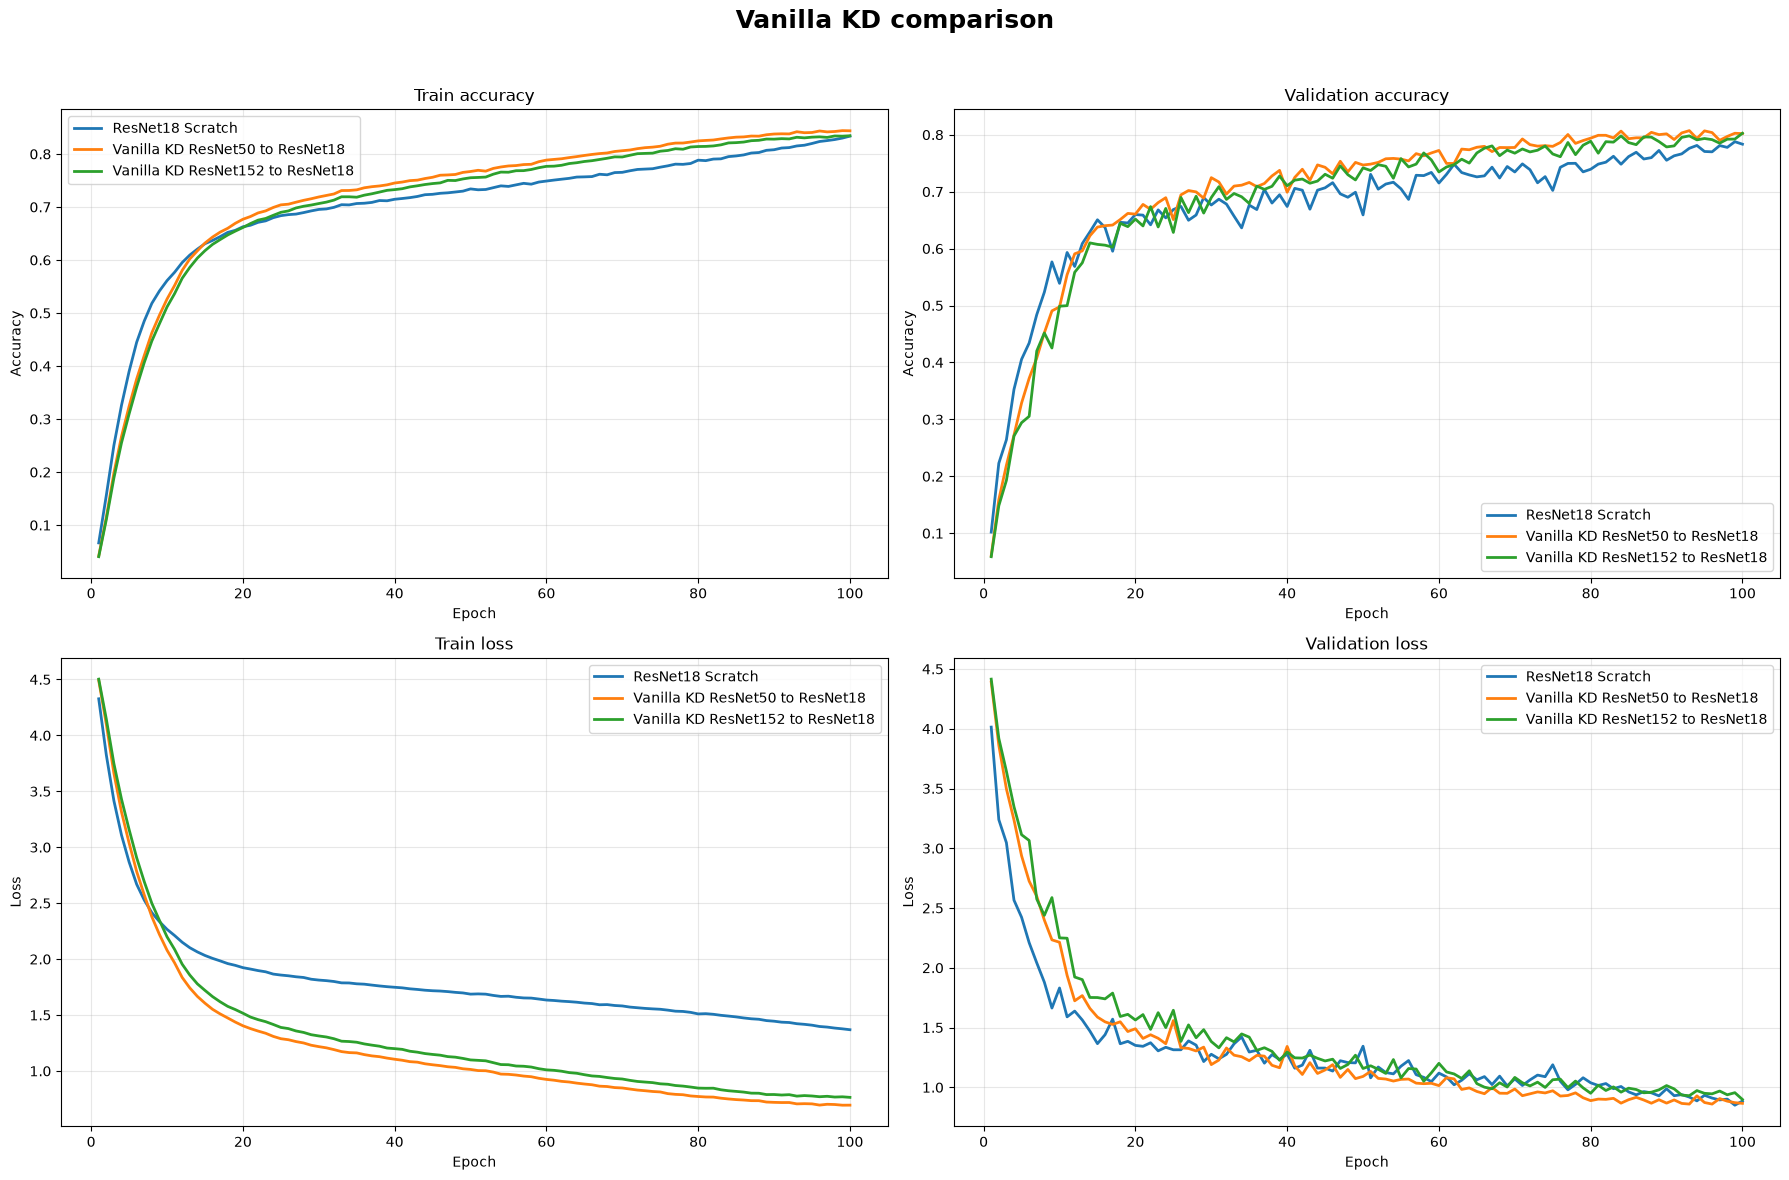

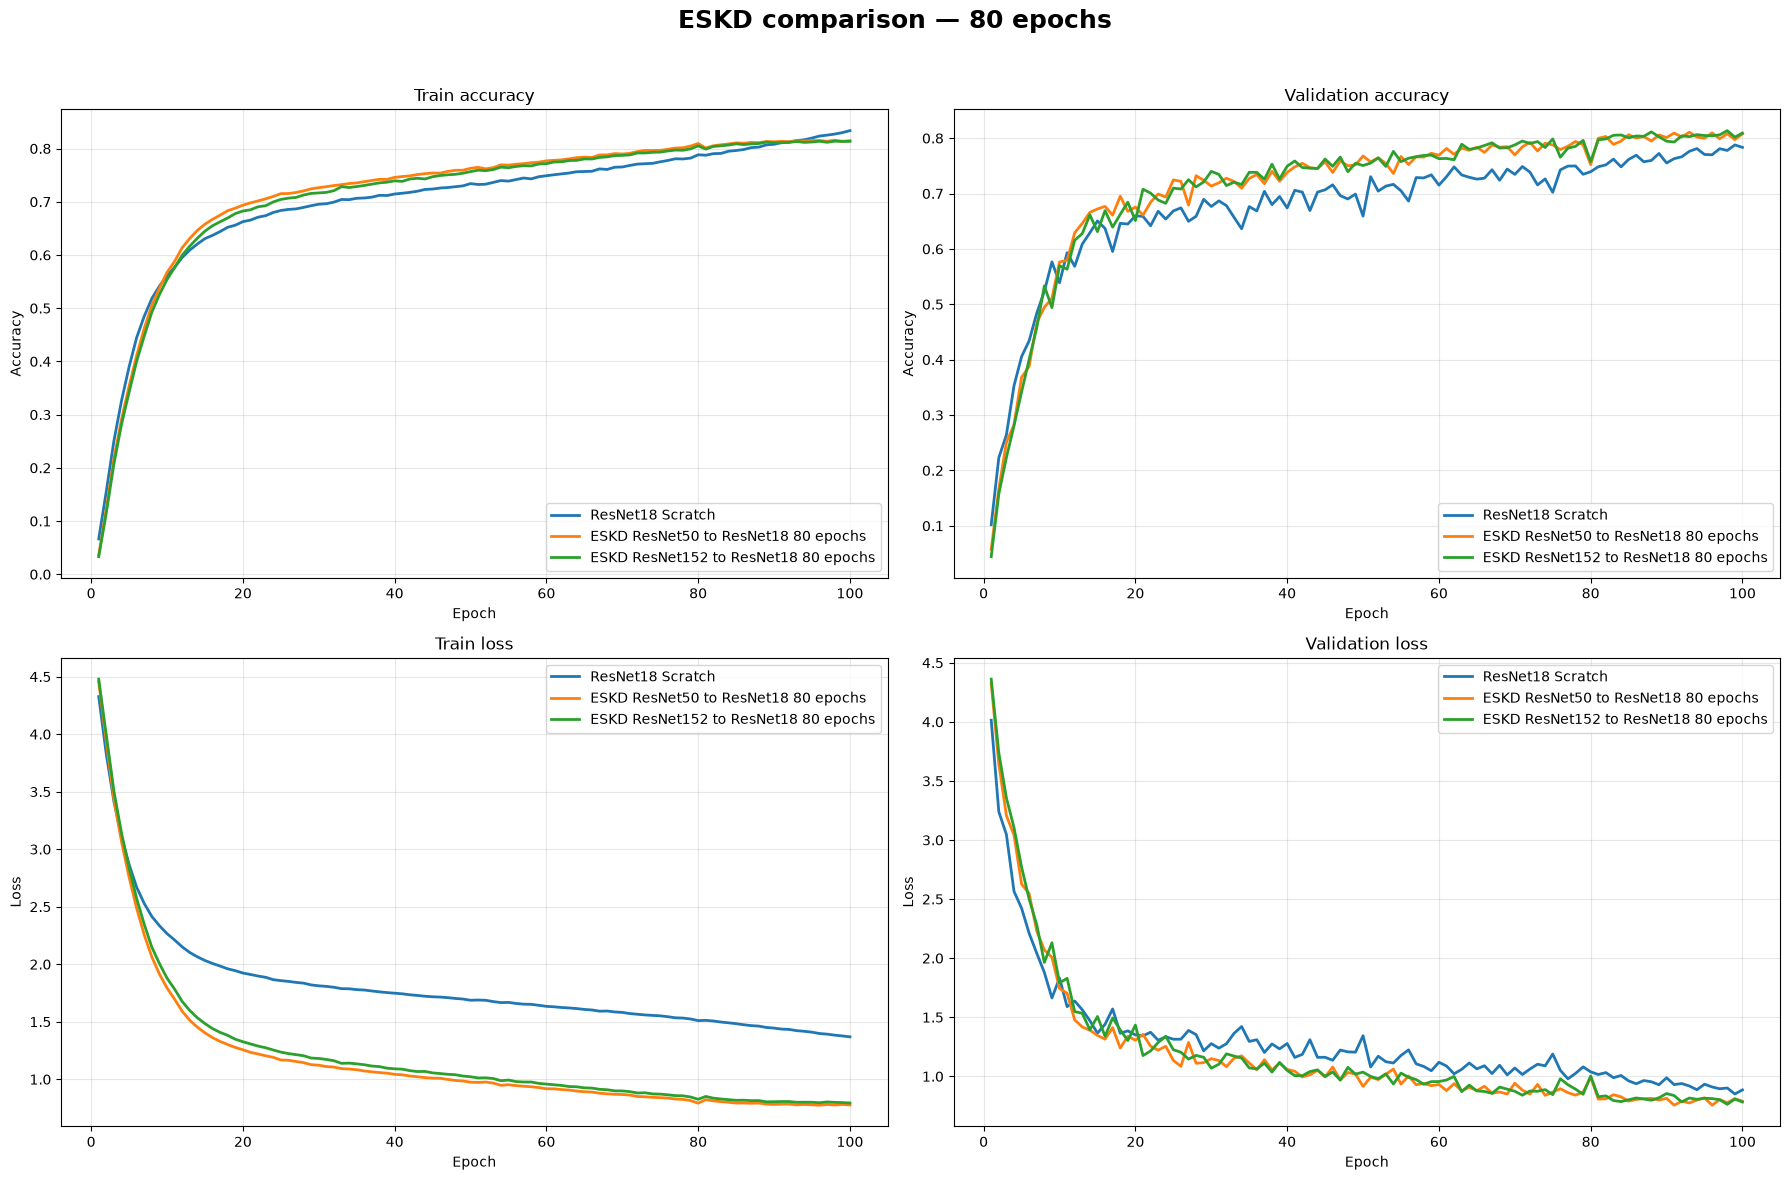

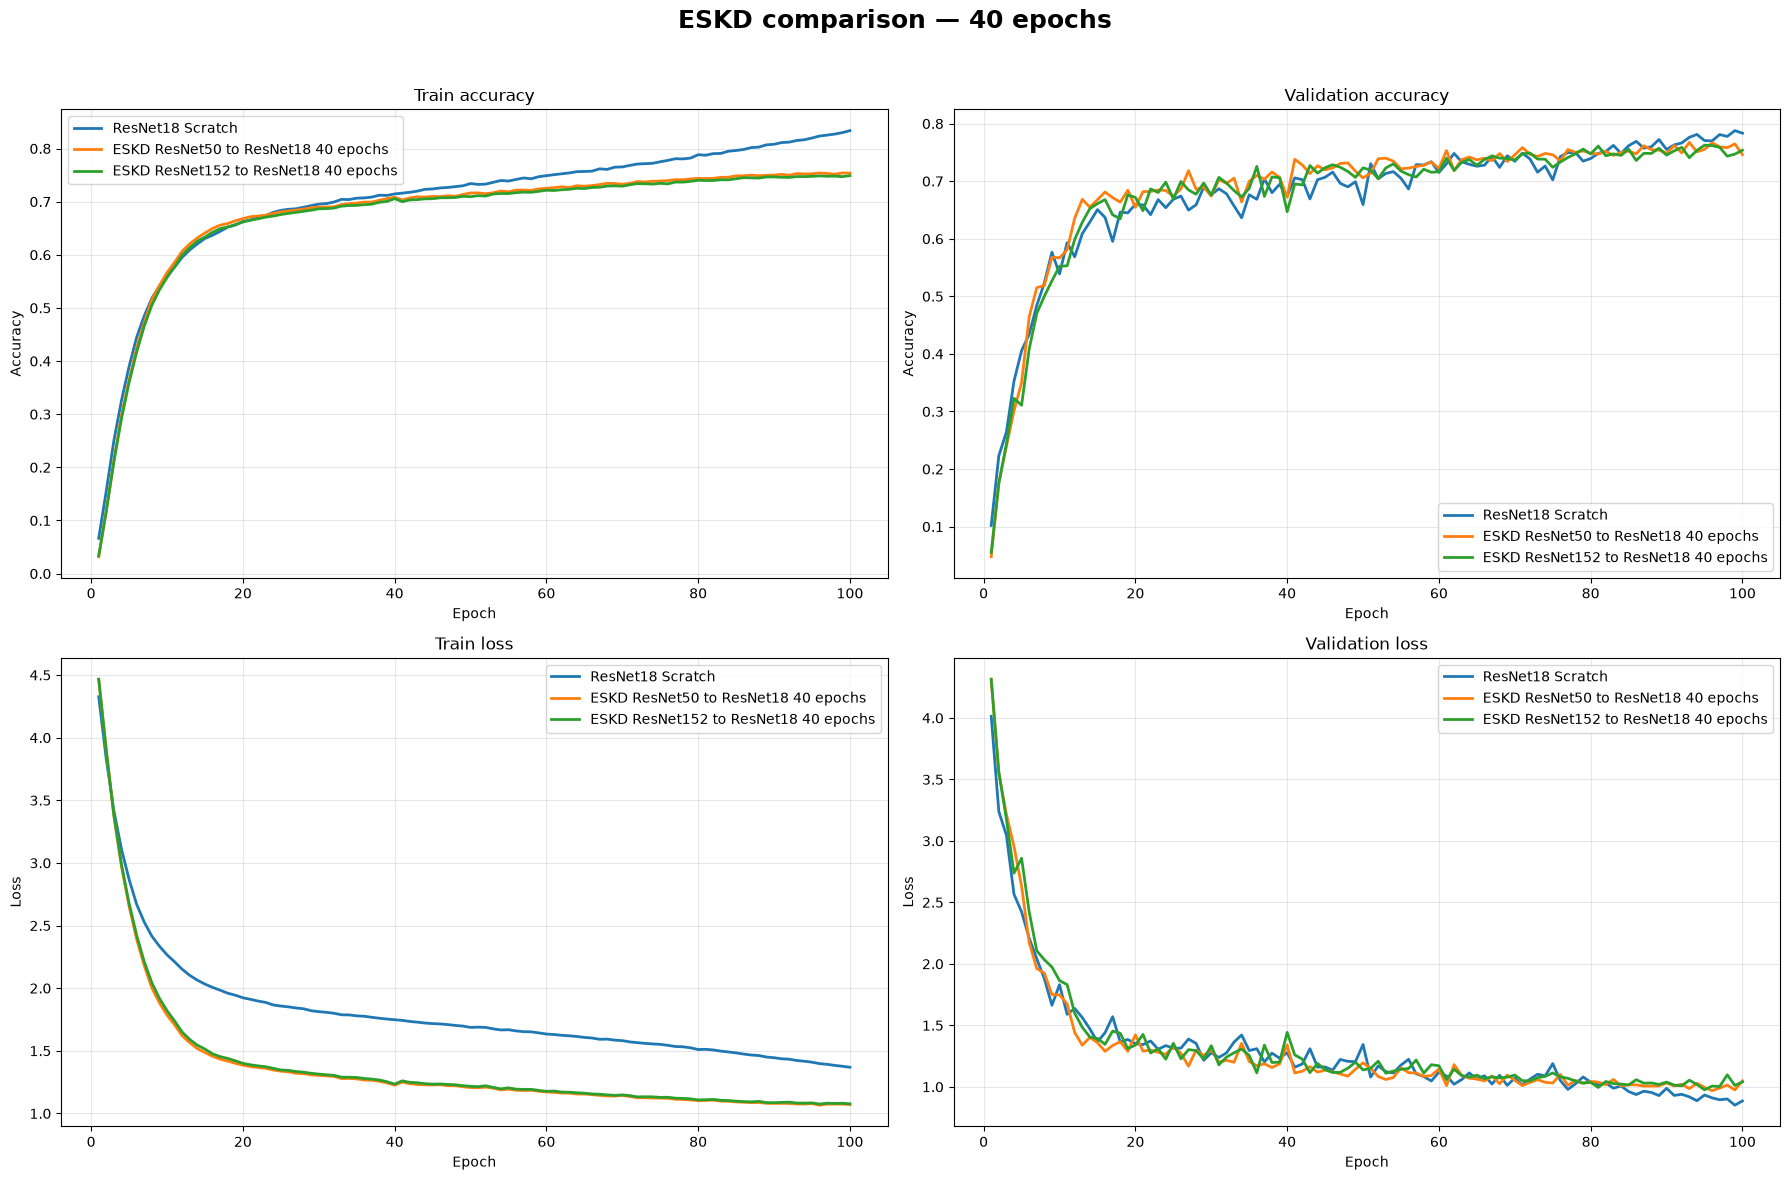

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Пути к историям обучения
history_paths = {
    "ResNet18 Scratch": (
        "../data/weights/resnet18_imagenet100/scratch/history.csv"
    ),
    "Vanilla KD ResNet50 to ResNet18": (
        "../data/weights/resnet18_imagenet100/"
        "vanilla-KD_resnet50/history.csv"
    ),
    "Vanilla KD ResNet152 to ResNet18": (
        "../data/weights/resnet18_imagenet100/"
        "vanilla-KD_resnet152/history.csv"
    ),
    "ESKD ResNet50 to ResNet18 80 epochs": (
        "../data/weights/resnet18_imagenet100/"
        "ESKD_resnet50_80_epochs/history.csv"
    ),
    "ESKD ResNet152 to ResNet18 80 epochs": (
        "../data/weights/resnet18_imagenet100/"
        "ESKD_resnet152_80_epochs/history.csv"
    ),
    "ESKD ResNet50 to ResNet18 40 epochs": (
        "../data/weights/resnet18_imagenet100/"
        "ESKD_resnet50_40_epochs/history.csv"
    ),
    "ESKD ResNet152 to ResNet18 40 epochs": (
        "../data/weights/resnet18_imagenet100/"
        "ESKD_resnet152_40_epochs/history.csv"
    ),
}


# Загружаем CSV только один раз
histories = {}

for experiment_name, history_path in history_paths.items():
    path = Path(history_path)

    if not path.exists():
        raise FileNotFoundError(
            f"История для эксперимента '{experiment_name}' не найдена:\n"
            f"{path.resolve()}"
        )

    histories[experiment_name] = pd.read_csv(path)


# Группы сравнения
experiment_groups = {
    "Vanilla KD comparison": [
        "ResNet18 Scratch",
        "Vanilla KD ResNet50 to ResNet18",
        "Vanilla KD ResNet152 to ResNet18",
    ],
    "ESKD comparison — 80 epochs": [
        "ResNet18 Scratch",
        "ESKD ResNet50 to ResNet18 80 epochs",
        "ESKD ResNet152 to ResNet18 80 epochs",
    ],
    "ESKD comparison — 40 epochs": [
        "ResNet18 Scratch",
        "ESKD ResNet50 to ResNet18 40 epochs",
        "ESKD ResNet152 to ResNet18 40 epochs",
    ],
}


# Какие метрики рисовать
metrics = {
    "train_acc": {
        "title": "Train accuracy",
        "ylabel": "Accuracy",
    },
    "eval_acc": {
        "title": "Validation accuracy",
        "ylabel": "Accuracy",
    },
    "train_ce": {
        "title": "Train loss",
        "ylabel": "Loss",
    },
    "eval_loss": {
        "title": "Validation loss",
        "ylabel": "Loss",
    },
}


def plot_experiment_group(
    group_name: str,
    experiment_names: list[str],
) -> None:
    """Строит четыре совмещённых графика для группы экспериментов."""

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(18, 12),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, (metric_name, metric_info) in zip(axes, metrics.items()):
        for experiment_name in experiment_names:
            history = histories[experiment_name]

            required_columns = {"epoch", metric_name}
            missing_columns = required_columns - set(history.columns)

            if missing_columns:
                raise KeyError(
                    f"В истории '{experiment_name}' отсутствуют столбцы: "
                    f"{sorted(missing_columns)}"
                )

            ax.plot(
                history["epoch"],
                history[metric_name],
                label=experiment_name,
                linewidth=2,
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_info["ylabel"])
        ax.set_title(metric_info["title"])
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(
        group_name,
        fontsize=18,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Строим отдельную фигуру для каждой группы
for group_name, experiment_names in experiment_groups.items():
    plot_experiment_group(
        group_name=group_name,
        experiment_names=experiment_names,
    )

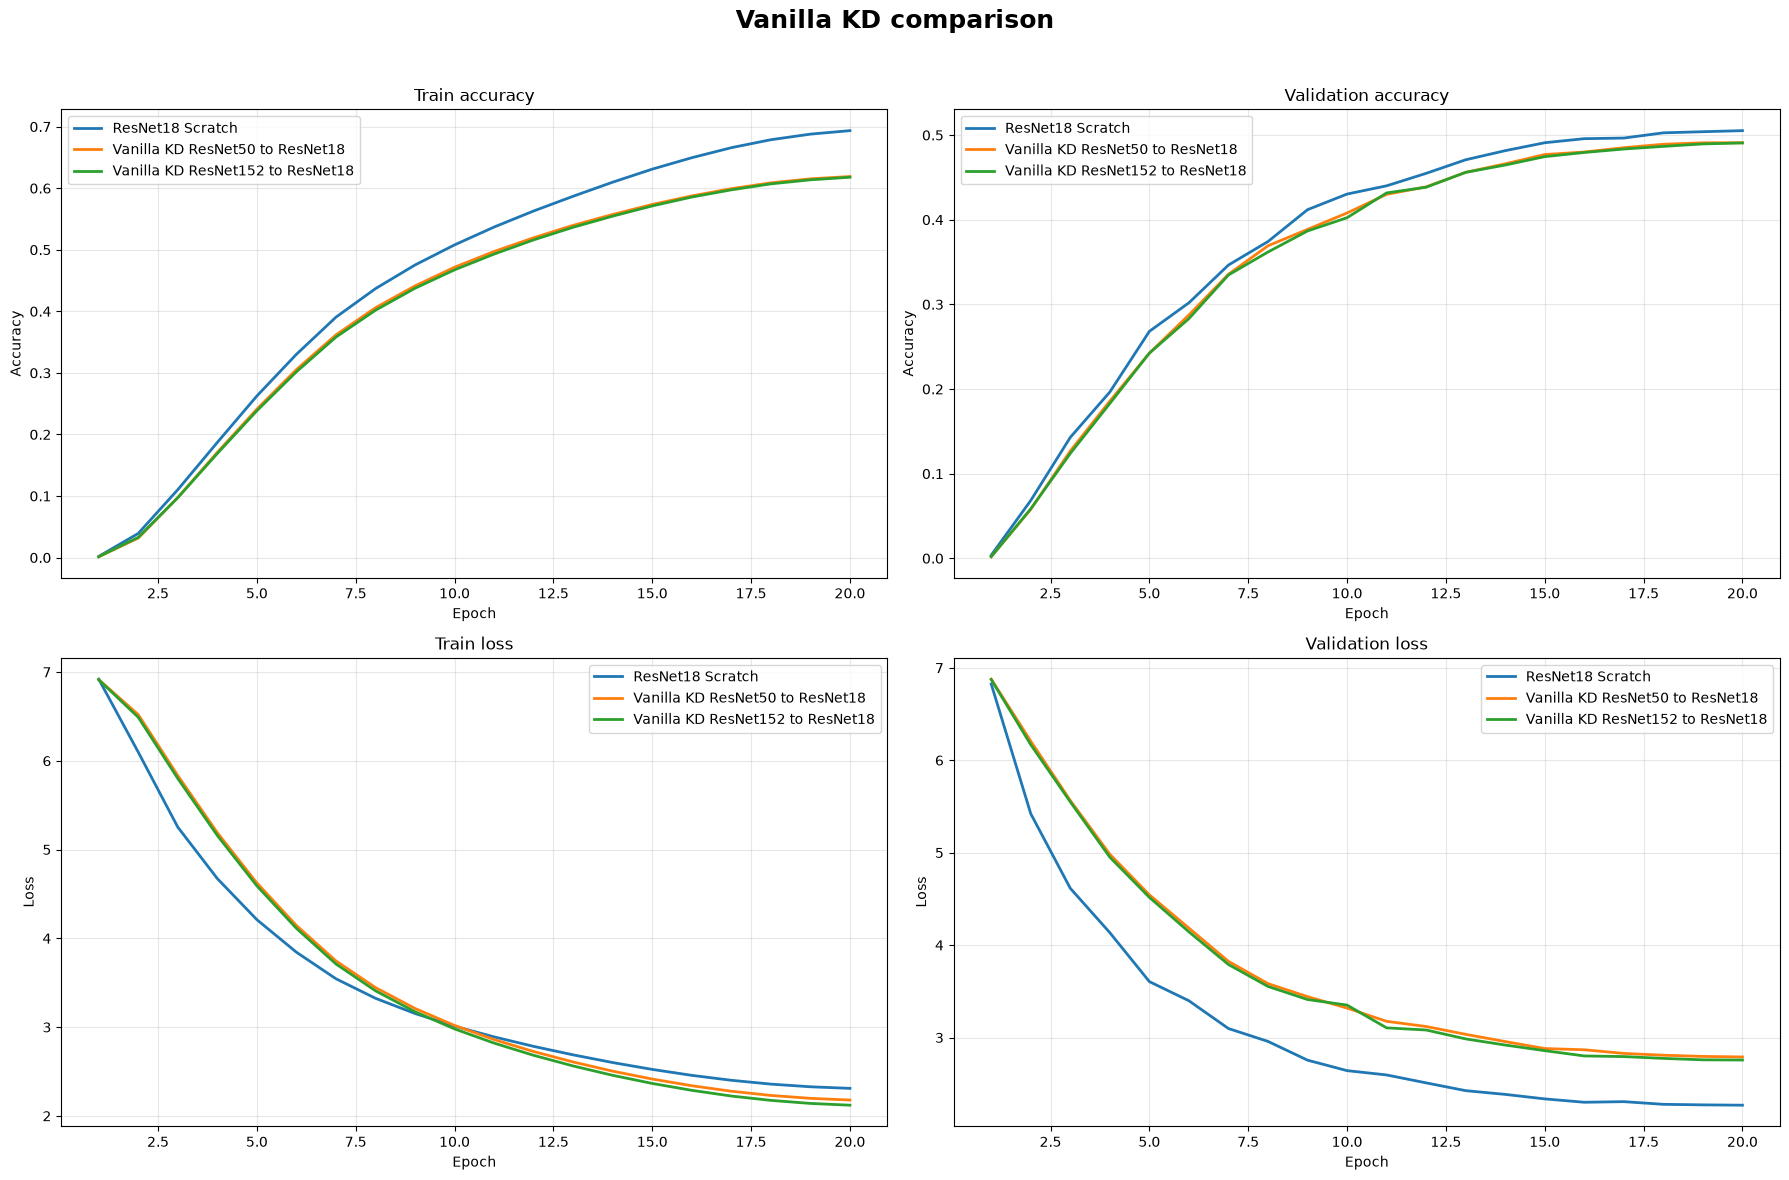

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Пути к историям обучения
history_paths = {
    "ResNet18 Scratch": (
        "../data/weights/resnet18_imagenet1k/scratch/history.csv"
    ),
    "Vanilla KD ResNet50 to ResNet18": (
        "../data/weights/resnet18_imagenet1k/"
        "vanilla-KD_resnet50/history.csv"
    ),
    "Vanilla KD ResNet152 to ResNet18": (
        "../data/weights/resnet18_imagenet1k/"
        "vanilla-KD_resnet152/history.csv"
    )
}


# Загружаем CSV только один раз
histories = {}

for experiment_name, history_path in history_paths.items():
    path = Path(history_path)

    if not path.exists():
        raise FileNotFoundError(
            f"История для эксперимента '{experiment_name}' не найдена:\n"
            f"{path.resolve()}"
        )

    histories[experiment_name] = pd.read_csv(path)


# Группы сравнения
experiment_groups = {
    "Vanilla KD comparison": [
        "ResNet18 Scratch",
        "Vanilla KD ResNet50 to ResNet18",
        "Vanilla KD ResNet152 to ResNet18",
    ]
}


# Какие метрики рисовать
metrics = {
    "train_acc": {
        "title": "Train accuracy",
        "ylabel": "Accuracy",
    },
    "eval_acc": {
        "title": "Validation accuracy",
        "ylabel": "Accuracy",
    },
    "train_ce": {
        "title": "Train loss",
        "ylabel": "Loss",
    },
    "eval_loss": {
        "title": "Validation loss",
        "ylabel": "Loss",
    },
}


def plot_experiment_group(
    group_name: str,
    experiment_names: list[str],
) -> None:
    """Строит четыре совмещённых графика для группы экспериментов."""

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(18, 12),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, (metric_name, metric_info) in zip(axes, metrics.items()):
        for experiment_name in experiment_names:
            history = histories[experiment_name]

            required_columns = {"epoch", metric_name}
            missing_columns = required_columns - set(history.columns)

            if missing_columns:
                raise KeyError(
                    f"В истории '{experiment_name}' отсутствуют столбцы: "
                    f"{sorted(missing_columns)}"
                )

            ax.plot(
                history["epoch"],
                history[metric_name],
                label=experiment_name,
                linewidth=2,
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_info["ylabel"])
        ax.set_title(metric_info["title"])
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(
        group_name,
        fontsize=18,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Строим отдельную фигуру для каждой группы
for group_name, experiment_names in experiment_groups.items():
    plot_experiment_group(
        group_name=group_name,
        experiment_names=experiment_names,
    )